# 可选实验 - Softmax 函数
在本实验中，我们将探索 softmax 函数。解决多分类问题时，该函数既用于 Softmax 回归，也用于神经网络。

<center>  <img  src="../work/images/C2_W2_Softmax_Header.PNG" width="600" />  <center/>

  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from IPython.display import display, Markdown, Latex
from sklearn.datasets import make_blobs
%matplotlib widget
from matplotlib.widgets import Slider
from lab_utils_common import dlc
from lab_utils_softmax import plt_softmax
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

> **注意**：通常，本课程的 notebook 采用从 0 开始计数、到 N-1 结束的约定，即 $\sum_{i=0}^{N-1}$；而课程讲解则从 1 开始、到 N 结束，即 $\sum_{i=1}^{N}$。这是因为代码通常从 0 开始迭代，而在课程讲解中，从 1 数到 N 可以得到更简洁明了的公式。本 notebook 中的公式比一般实验更多，因此将打破惯例，采用从 1 到 N 的计数方式。

## Softmax 函数
在 softmax 回归和具有 Softmax 输出的神经网络中，都会生成 N 个输出，并选择其中一个作为预测类别。在这两种情况下，线性函数都会生成一个向量 $\mathbf{z}$，然后对其应用 softmax 函数。softmax 函数会按下面所述将 $\mathbf{z}$ 转换为概率分布。应用 softmax 后，每个输出都位于 0 和 1 之间，且所有输出之和为 1，因此可以将它们解释为概率。较大的输入对应较大的输出概率。
<center>  <img  src="../work/images/C2_W2_SoftmaxReg_NN.png" width="600" />  

softmax 函数可以写为：
$$a_j = \frac{e^{z_j}}{ \sum_{k=1}^{N}{e^{z_k} }} \tag{1}$$
输出 $\mathbf{a}$ 是长度为 N 的向量，因此对于 softmax 回归，也可以写为：
\begin{align}
\mathbf{a}(x) =
\begin{bmatrix}
P(y = 1 | \mathbf{x}; \mathbf{w},b) \\
\vdots \\
P(y = N | \mathbf{x}; \mathbf{w},b)
\end{bmatrix}
=
\frac{1}{ \sum_{k=1}^{N}{e^{z_k} }}
\begin{bmatrix}
e^{z_1} \\
\vdots \\
e^{z_{N}} \\
\end{bmatrix} \tag{2}
\end{align}

这表明输出是一个概率向量。第一个条目表示：给定输入 $\mathbf{x}$ 和参数 $\mathbf{w}$、$\mathbf{b}$ 时，该输入属于第一个类别的概率。
让我们创建一个 NumPy 实现：

In [2]:
def my_softmax(z):
    ez = np.exp(z)              #element-wise exponenial
    sm = ez/np.sum(ez)
    return(sm)

在下方使用滑块改变 `z` 输入的值。

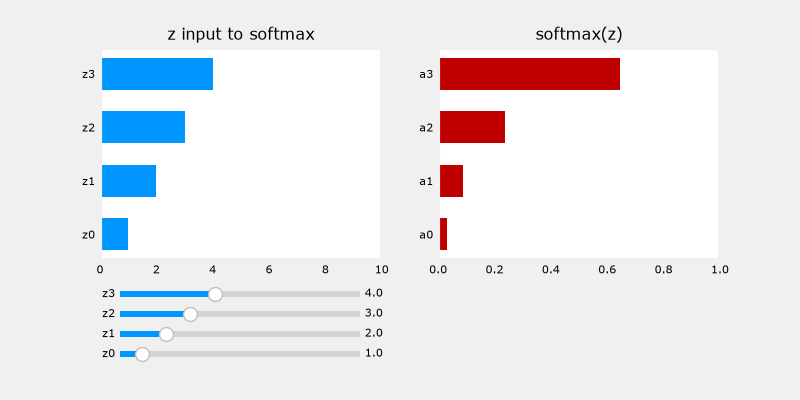

In [3]:
plt.close("all")
plt_softmax(my_softmax)

当你改变上面各个 z 的值时，有几点需要注意：
* softmax 分子中的指数会放大数值间的微小差异
* 输出值之和为 1
* softmax 会作用于所有输出。例如，`z0` 的变化会改变 `a0`-`a3` 的值。与 ReLU 或 Sigmoid 等其他激活函数相比，后者只有一个输入和一个输出。

## 代价
<center> <img  src="../work/images/C2_W2_SoftMaxCost.png" width="400" />    <center/>

与 Softmax 相关的损失函数，即交叉熵损失，为：
\begin{equation}
  L(\mathbf{a},y)=\begin{cases}
    -log(a_1), & \text{if $y=1$}.\\
        &\vdots\\
     -log(a_N), & \text{if $y=N$}
  \end{cases} \tag{3}
\end{equation}

其中 y 是该样本的目标类别，$\mathbf{a}$ 是 softmax 函数的输出。具体来说，$\mathbf{a}$ 中的值是总和为一的概率。
>**回顾：** 在本课程中，损失针对一个样本，而代价涵盖所有样本。
 
 
请注意，在上面的 (3) 中，只有与目标对应的那一行会对损失产生贡献，其他行均为零。为了写出代价公式，需要一个“指示函数”：索引与目标匹配时为 1，否则为 0。
    $$\mathbf{1}\{y == n\} = =\begin{cases}
    1, & \text{if $y==n$}.\\
    0, & \text{otherwise}.
  \end{cases}$$
现在代价为：
\begin{align}
J(\mathbf{w},b) = - \left[ \sum_{i=1}^{m} \sum_{j=1}^{N}  1\left\{y^{(i)} == j\right\} \log \frac{e^{z^{(i)}_j}}{\sum_{k=1}^N e^{z^{(i)}_k} }\right] \tag{4}
\end{align}

其中 $m$ 是样本数量，$N$ 是输出数量。这是所有损失的平均值。

## TensorFlow
本实验将讨论在 TensorFlow 中实现 softmax 交叉熵损失的两种方式：“直观”方法和“推荐”方法。前者最直接，后者在数值上更稳定。

先创建一个数据集，用于训练多分类模型。

In [5]:
# make  dataset for example
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
X_train, y_train = make_blobs(n_samples=2000, centers=centers, cluster_std=1.0,random_state=30)

### *直观的*组织方式

下面的模型在最后一个密集层中将 softmax 实现为激活函数。
损失函数则在 `compile` 指令中单独指定。

损失函数为 `SparseCategoricalCrossentropy`，也就是上面公式 (3) 描述的损失。在此模型中，softmax 位于最后一层。损失函数接收 softmax 的输出，即一个概率向量。

In [12]:
model = Sequential(
    [ 
        Dense(25, activation = 'relu'),
        Dense(15, activation = 'relu'),
        Dense(4, activation = 'softmax')    # < softmax activation here
    ]
)
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X_train,y_train,
    epochs=10
)
        

AttributeError: module 'keras._tf_keras.keras.losses' has no attribute 'CategoricalCrossEntropy'

由于 softmax 已集成到输出层中，因此输出是一个概率向量。

In [7]:
p_nonpreferred = model.predict(X_train)
print(p_nonpreferred [:2])
print("largest value", np.max(p_nonpreferred), "smallest value", np.min(p_nonpreferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[4.69e-03 5.58e-03 9.70e-01 1.94e-02]
 [9.94e-01 5.17e-03 5.16e-04 1.46e-04]]
largest value 0.9999989 smallest value 1.5489368e-09


### 推荐的 <img align="Right" src="../work/images/C2_W2_softmax_accurate.png"  style=" width:400px; padding: 10px 20px ; ">
回顾课程内容，如果在训练期间将 softmax 与损失结合起来，可以得到更稳定、更准确的结果。这里所示的“推荐”组织方式可实现这一点。

在首选的组织方式中，最后一层采用线性激活。由于历史原因，这种形式的输出称为 *logits*（逻辑值）。损失函数还有一个额外参数：`from_logits = True`。它会告知损失函数，应在损失计算中包含 softmax 运算，从而允许使用经过优化的实现。

In [8]:
preferred_model = Sequential(
    [ 
        Dense(25, activation = 'relu'),
        Dense(15, activation = 'relu'),
        Dense(4, activation = 'linear')   #<-- Note
    ]
)
preferred_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  #<-- Note
    optimizer=tf.keras.optimizers.Adam(0.001),
)

preferred_model.fit(
    X_train,y_train,
    epochs=10
)
        

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0974
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5316
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.2497
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1341
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0907
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0707
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0594
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0519
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0466
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0426


#### 输出处理
请注意，在首选模型中，输出并不是概率，而是可以从很大的负数变化到很大的正数。当进行期望得到概率的预测时，必须将输出传入 softmax。
让我们看看首选模型的输出：

In [9]:
p_preferred = preferred_model.predict(X_train)
print(f"two example output vectors:\n {p_preferred[:2]}")
print("largest value", np.max(p_preferred), "smallest value", np.min(p_preferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
two example output vectors:
 [[-1.75 -1.14  4.55  1.  ]
 [ 6.37  1.54 -3.59 -4.68]]
largest value 12.63114 smallest value -6.9204473


输出预测值并不是概率！
如果期望的输出是概率，则应使用 [softmax](https://www.tensorflow.org/api_docs/python/tf/nn/softmax) 处理输出。

In [10]:
sm_preferred = tf.nn.softmax(p_preferred).numpy()
print(f"two example output vectors:\n {sm_preferred[:2]}")
print("largest value", np.max(sm_preferred), "smallest value", np.min(sm_preferred))

two example output vectors:
 [[1.78e-03 3.28e-03 9.67e-01 2.79e-02]
 [9.92e-01 7.90e-03 4.69e-05 1.57e-05]]
largest value 0.9999951 smallest value 1.4312631e-08


选择最可能的类别时并不需要 softmax。可以使用 [np.argmax()](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) 找到最大输出的索引。

In [11]:
for i in range(5):
    print( f"{p_preferred[i]}, category: {np.argmax(p_preferred[i])}")

[-1.75 -1.14  4.55  1.  ], category: 2
[ 6.37  1.54 -3.59 -4.68], category: 0
[ 4.62  1.59 -2.84 -3.84], category: 0
[-0.79  3.63 -2.3  -2.59], category: 1
[ 0.25 -1.38  5.78 -0.8 ], category: 2


## SparseCategoricalCrossentropy 或 CategoricalCrossEntropy
TensorFlow 的目标值有两种可能格式，所选择的损失函数决定了预期使用哪一种格式。
- SparseCategoricalCrossentropy：要求目标值为与索引对应的整数。例如，如果有 10 个可能的目标值，则 y 应介于 0 和 9 之间。
- CategoricalCrossEntropy：要求样本的目标值采用独热编码，即目标索引处的值为 1，而其他 N-1 个条目均为零。例如，有 10 个可能的目标值且目标为 2 时，其编码为 [0,0,1,0,0,0,0,0,0,0]。

## 恭喜！
在本实验中，您：
- 更加熟悉了 softmax 函数及其在 softmax 回归和神经网络 softmax 激活中的用法；
- 学会了 TensorFlow 中推荐的模型构建方式：
    - 最后一层不使用激活函数（等同于线性激活）；
    - 使用 SparseCategoricalCrossentropy 损失函数；
    - 使用 from_logits=True；
- 认识到与 ReLU 和 Sigmoid 不同，softmax 会跨越多个输出。

## 数值稳定性（可选）
本节讨论一些用于提高数值稳定性的方法。这些内容仅供感兴趣的读者阅读，并非必需。

### Softmax 的数值稳定性
softmax 的输入是线性层的输出 $z_j = \mathbf{w_j} \cdot \mathbf{x}^{(i)}+b$，这些值可能很大。softmax 算法的第一步计算 $e^{z_j}$。如果数值过大，可能会导致溢出错误。尝试运行下面的单元格：

In [13]:
for z in [500,600,700,800]:
    ez = np.exp(z)
    zs = "{" + f"{z}" + "}"
    print(f"e^{zs} = {ez:0.2e}")

e^{500} = 1.40e+217
e^{600} = 3.77e+260
e^{700} = 1.01e+304
e^{800} = inf


C:\Windows\Temp\ipykernel_2764\1141864107.py:2: RuntimeWarning: overflow encountered in exp
  ez = np.exp(z)


如果指数过大，该运算将产生溢出。自然地，`my_softmax()` 也会产生相同的错误：

In [14]:
z_tmp = np.array([[500,600,700,800]])
my_softmax(z_tmp)

C:\Windows\Temp\ipykernel_2764\1989128138.py:2: RuntimeWarning: overflow encountered in exp
  ez = np.exp(z)              #element-wise exponenial
C:\Windows\Temp\ipykernel_2764\1989128138.py:3: RuntimeWarning: invalid value encountered in divide
  sm = ez/np.sum(ez)


array([[ 0.,  0.,  0., nan]])

可以通过减小指数的大小来提高数值稳定性。
回顾一下：
$$ e^{a + b} = e^ae^b$$
如果 $b$ 的符号与 $a$ 相反，就能减小指数的大小。具体而言，如果将 softmax 乘以一个分数：
$$a_j = \frac{e^{z_j}}{ \sum_{i=1}^{N}{e^{z_i} }} \frac{e^{-b}}{ {e^{-b}}}$$
指数会减小，而 softmax 的值不会改变。如果 $e^b$ 中的 $b$ 是各个 $z_j$ 中的最大值，即 $max_j(\mathbf{z})$，指数将被减小到最小值。
$$\begin{align}
a_j &= \frac{e^{z_j}}{ \sum_{i=1}^{N}{e^{z_i} }} \frac{e^{-max_j(\mathbf{z})}}{ {e^{-max_j(\mathbf{z})}}} \\
&= \frac{e^{z_j-max_j(\mathbf{z})}}{ \sum_{i=1}^{N}{e^{z_i-max_j(\mathbf{z})} }} 
\end{align}$$
通常写作 $C=max_j(\mathbf{z})$，因为对于任意常数 C，该方程都成立。

$$
a_j = \frac{e^{z_j-C}}{ \sum_{i=1}^{N}{e^{z_i-C} }} \quad\quad\text{where}\quad C=max_j(\mathbf{z})\tag{5}
$$

如果查看棘手示例，其中 $\mathbf{z}$ 包含 500、600、700、800，则 $C=max_j(\mathbf{z})=800$：
\begin{align}
\mathbf{a}(x) =
\frac{1}{ e^{500-800} + e^{600-800} + e^{700-800} + e^{800-800}}
\begin{bmatrix}
e^{500-800} \\
e^{600-800} \\
e^{700-800} \\
e^{800-800} \\
\end{bmatrix}
= 
\begin{bmatrix}
5.15e-131 \\
1.38e-87 \\
3.7e-44 \\
1.0 \\
\end{bmatrix}
\end{align}

让我们重写 `my_softmax`，以提高其数值稳定性。

In [15]:
def my_softmax_ns(z):
    """numerically stablility improved"""
    bigz = np.max(z)
    ez = np.exp(z-bigz)              # minimize exponent
    sm = ez/np.sum(ez)
    return(sm)

让我们试一下，并将其与 TensorFlow 的实现进行比较：

In [16]:
z_tmp = np.array([500.,600,700,800])
print(tf.nn.softmax(z_tmp).numpy(), "\n", my_softmax_ns(z_tmp))

[5.15e-131 1.38e-087 3.72e-044 1.00e+000] 
 [5.15e-131 1.38e-087 3.72e-044 1.00e+000]


较大的值不再导致溢出。

### 交叉熵损失的数值稳定性

这里再次给出与 Softmax 相关的损失函数，即交叉熵损失：
\begin{equation}
  L(\mathbf{a},y)=\begin{cases}
    -log(a_1), & \text{if $y=1$}.\\
        &\vdots\\
     -log(a_N), & \text{if $y=N$}
  \end{cases}
\end{equation}

其中 y 是该样本的目标类别，$\mathbf{a}$ 是 softmax 函数的输出。具体来说，$\mathbf{a}$ 中的值是总和为一的概率。
考虑目标为二（$y=2$）的情况，并只观察该情况下的损失。此时损失为：  
$$L(\mathbf{a})= -log(a_2)$$
回想一下，$a_2$ 是上述 softmax 函数的输出，因此可以写为：
$$L(\mathbf{z})= -log\left(\frac{e^{z_2}}{ \sum_{i=1}^{N}{e^{z_i} }}\right) \tag{6}$$
这可以进一步优化。但要进行这些优化，必须像上面看到的 TensorFlow“首选”实现那样，将 softmax 和损失放在一起计算。

从上面的公式 (6) 出发，当 y=2 时，损失为：
$log(\frac{a}{b}) = log(a) - log(b)$，因此可以将 (6) 改写为：
$$L(\mathbf{z})= -\left[log(e^{z_2}) - log \sum_{i=1}^{N}{e^{z_i} }\right] \tag{7}$$
第一项可以简化为 $z_2$：
$$L(\mathbf{z})= -\left[z_2 - log( \sum_{i=1}^{N}{e^{z_i} })\right] =  \underbrace{log \sum_{i=1}^{N}{e^{z_i} }}_\text{logsumexp()} -z_2 \tag{8}$$
事实证明，上式中的 $log \sum_{i=1}^{N}{e^{z_i} }$ 项使用得非常频繁，因此许多库都提供了实现。在 TensorFlow 中，它是 tf.math.reduce_logsumexp()。这个求和存在一个问题：如果 $z_i$ 很大，求和中的指数可能会溢出。为了解决这个问题，我们可能希望像上面一样减去 $e^{max_j(\mathbf{z})}$，但这需要做一些推导：
$$
\begin{align}
   log \sum_{i=1}^{N}{e^{z_i} } &= log \sum_{i=1}^{N}{e^{(z_i - max_j(\mathbf{z}) + max_j(\mathbf{z}))}} \tag{9}\\
                          &= log \sum_{i=1}^{N}{e^{(z_i - max_j(\mathbf{z}))} e^{max_j(\mathbf{z})}} \\
                          &= log(e^{max_j(\mathbf{z})}) + log \sum_{i=1}^{N}{e^{(z_i - max_j(\mathbf{z}))}} \\
                          &= max_j(\mathbf{z})  + log \sum_{i=1}^{N}{e^{(z_i - max_j(\mathbf{z}))}}
\end{align}
$$
现在，指数溢出的可能性降低了。通常令 $C=max_j(\mathbf{z})$，因为对于任意常数 C，该公式都成立。现在可以写出损失公式：
    
$$L(\mathbf{z})= C+ log( \sum_{i=1}^{N}{e^{z_i-C} }) -z_2  \;\;\;\text{where } C=max_j(\mathbf{z}) \tag{10} $$
这是计算更简单、数值更稳定的损失版本。上式针对目标 y=2 的样本，但可推广到任意目标值。